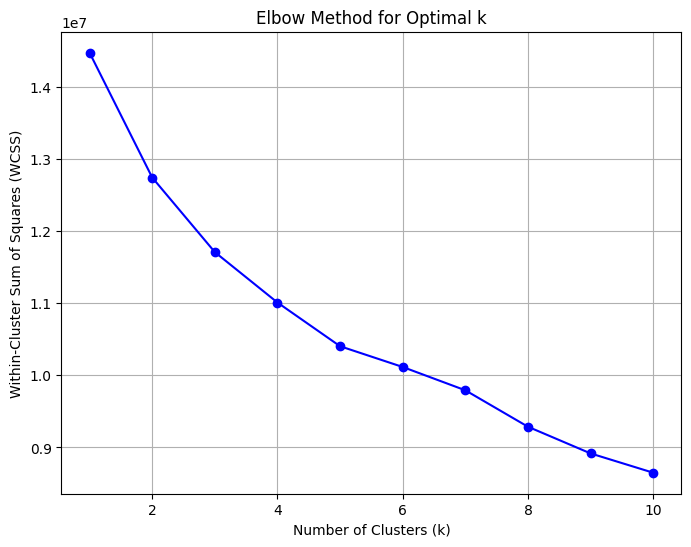

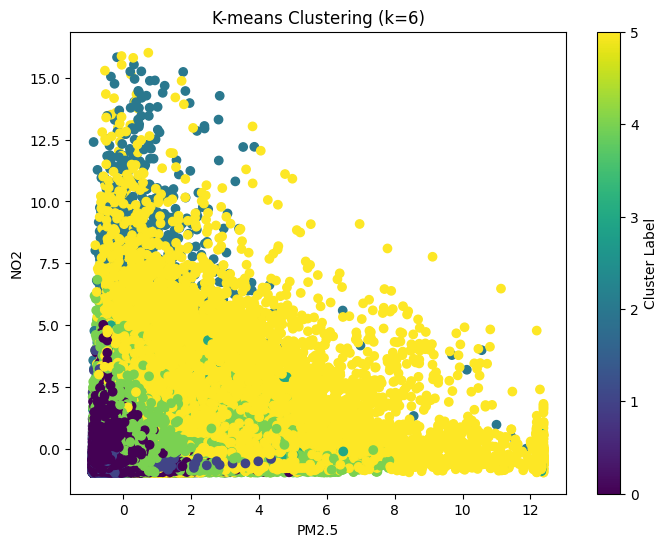

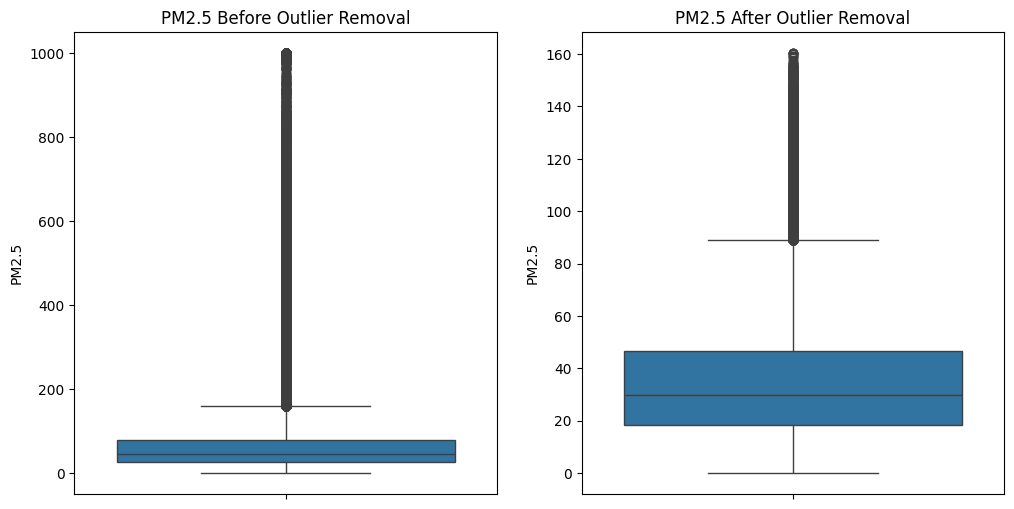

Selected Features: ['Latitude', 'Longitude', 'Urban_Density', 'PM2.5', 'PM10', 'NO', 'NO2', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Volatility_Index', 'O3_Rolling_Std', 'Pollution_Index', 'Lat_Long_Interaction', 'PM_Ratio', 'NOx']

=== KNN ===
Accuracy: 0.8281843631273745
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.88      0.74      4133
           1       0.81      0.85      0.83     12264
           2       0.59      0.80      0.68      1136
           3       0.92      0.81      0.86     22085
           4       0.36      0.68      0.47        19
           5       0.67      0.77      0.72       371

    accuracy                           0.83     40008
   macro avg       0.67      0.80      0.72     40008
weighted avg       0.84      0.83      0.83     40008



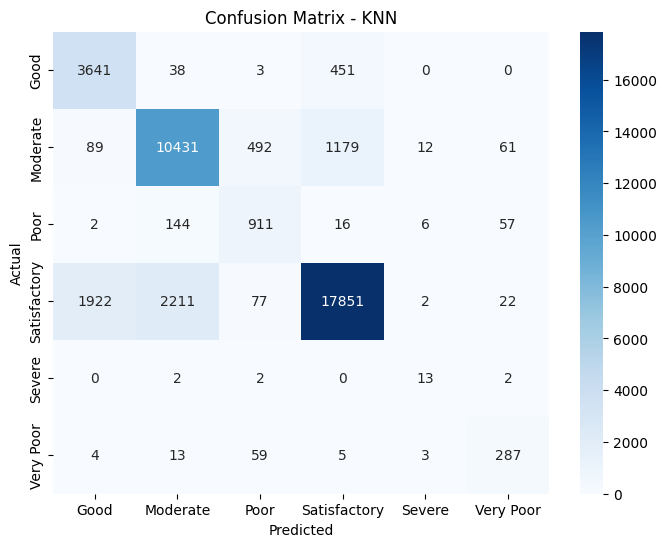


=== Naive Bayes ===
Accuracy: 0.8210485062253173
Classification Report:
               precision    recall  f1-score   support

           1       0.60      0.69      0.65      2441
           3       0.72      0.13      0.22      4296
           4       0.85      0.98      0.91     25500
           5       0.55      0.11      0.18       885
           6       0.00      0.00      0.00        49

    accuracy                           0.82     33171
   macro avg       0.55      0.38      0.39     33171
weighted avg       0.80      0.82      0.78     33171



C:\Users\Shayan\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shayan\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shayan\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

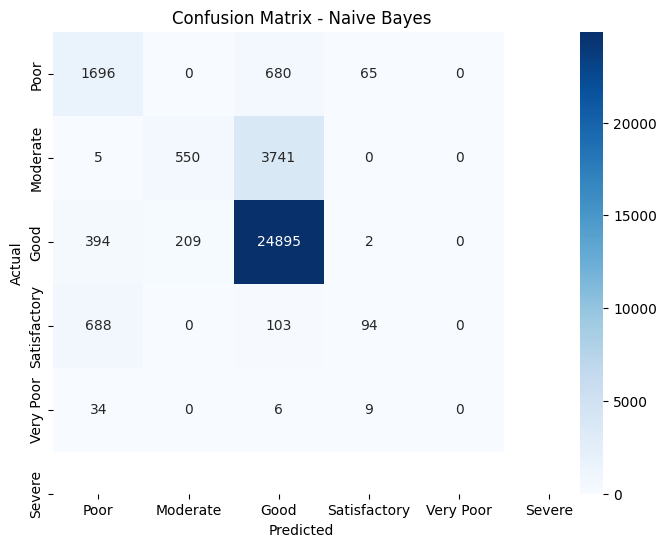


=== Random Forest ===
Accuracy: 0.8625774845030993
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.85      0.80      4133
           1       0.84      0.87      0.85     12264
           2       0.71      0.82      0.76      1136
           3       0.91      0.86      0.89     22085
           4       0.64      0.47      0.55        19
           5       0.84      0.80      0.81       371

    accuracy                           0.86     40008
   macro avg       0.78      0.78      0.78     40008
weighted avg       0.87      0.86      0.86     40008



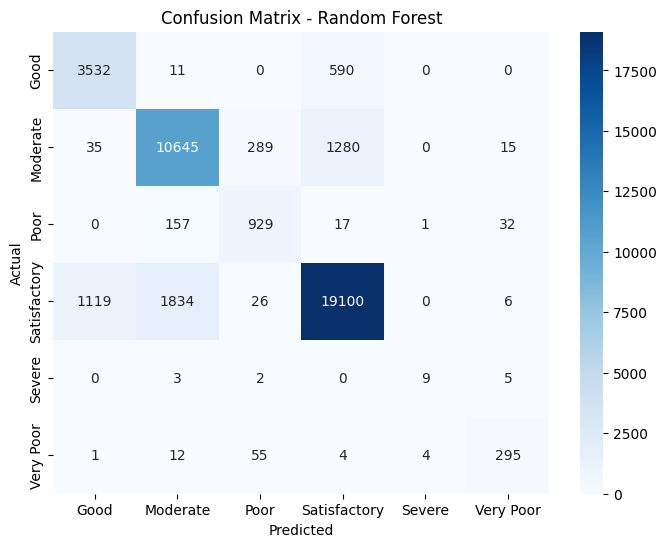

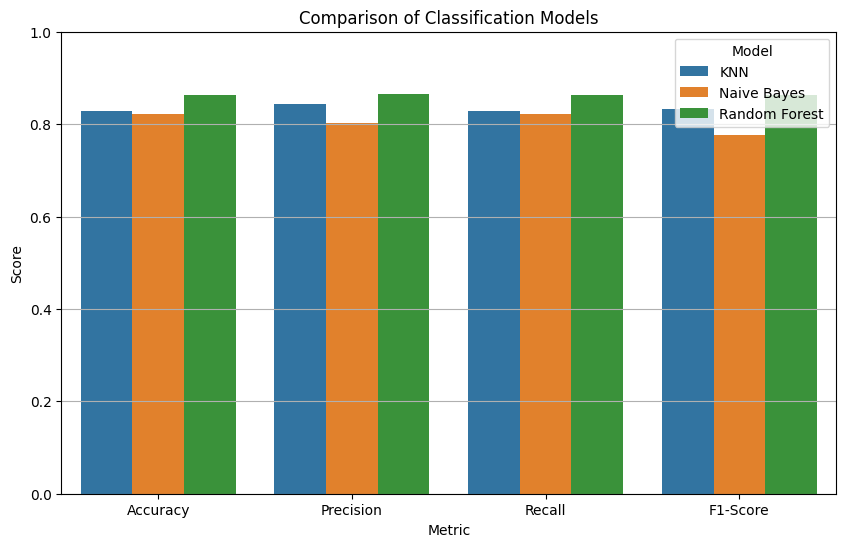

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('air_quality_feature.csv')  # Ensure correct path

# ------------------ K-Means Clustering ---------------
meanData = df.copy()
# Handle missing values by imputing with mean for numeric columns
if meanData.isnull().values.any():
    meanData.fillna(meanData.mean(numeric_only=True), inplace=True)
# Select only numerical columns for clustering
numerical_data = meanData.select_dtypes(include=np.number)

# Scale the numerical data
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(numerical_data),
                         columns=numerical_data.columns)

# Select numerical features for clustering
numerical_features = df_scaled.columns

# --- Elbow Method to Find Optimal k ---
wcss = []  # Within-Cluster Sum of Squares
k_range = range(1, 11)  # Test k from 1 to 20
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(df_scaled[numerical_features])
    wcss.append(kmeans.inertia_)  # Inertia_ is the WCSS

# Plot the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.show()

# --- K-Means Clustering with k=6 ---
k = 6
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
kmeans.fit(df_scaled[numerical_features])
cluster_labels = kmeans.labels_
df_scaled[f'cluster_{k}'] = cluster_labels

# --- Visualize Clusters for k=6 ---
x_axis = 'PM2.5'
y_axis = 'NO2'

# Create scatter plot for k=6
plt.figure(figsize=(8, 6))
plt.scatter(df_scaled[x_axis], df_scaled[y_axis], c=df_scaled[f'cluster_{k}'], cmap='viridis')
plt.title(f'K-means Clustering (k={k})')
plt.xlabel(x_axis)
plt.ylabel(y_axis)
plt.colorbar(label='Cluster Label')
plt.show()
# ----------------------------------------K-Means Clustering Done----------------------------------------
# Original DataFrame copy for boxplot comparison
df_original = df.copy()

# Features for both pipelines
features = ['Latitude', 'Longitude', 'Urban_Density', 'PM2.5', 'PM10', 'NO', 'NO2', 'NH3',
            'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Volatility_Index',
            'O3_Rolling_Std', 'Temperature', 'Humidity', 'Wind_Speed', 'Atmospheric_Pressure',
            'Pollution_Index', 'Lat_Long_Interaction', 'PM_Ratio', 'NOx']

# --- Naive Bayes Preprocessing (from standalone code) ---
df_nb = df[df['AQI_Bucket'].notnull()]
X_nb = df_nb[features]
y_nb = df_nb['AQI_Bucket']

# Handle missing values and outliers for Naive Bayes
X_nb = X_nb.fillna(X_nb.median(numeric_only=True))
Q1_nb = X_nb.quantile(0.25)
Q3_nb = X_nb.quantile(0.75)
IQR_nb = Q3_nb - Q1_nb
mask_nb = ~((X_nb < (Q1_nb - 1.5 * IQR_nb)) | (X_nb > (Q3_nb + 1.5 * IQR_nb))).any(axis=1)
X_nb = X_nb[mask_nb]
y_nb = y_nb[mask_nb]

# Reduce dominant class ("Moderate") for Naive Bayes
if "Moderate" in y_nb.values:
    dominant_index = y_nb[y_nb == "Moderate"].index
    dominant_index = np.random.permutation(dominant_index)
    reduce_index = dominant_index[0:(len(dominant_index) // 2) * 4]
    X_nb = X_nb.drop(reduce_index)
    y_nb = y_nb.drop(reduce_index)

# Encode target for Naive Bayes
class_dic = {
    "Poor": 1,
    "Moderate": 2,
    "Good": 3,
    "Satisfactory": 4,
    "Very Poor": 5,
    "Severe": 6
}
y_nb_encoded = y_nb.map(class_dic)

# Scale and apply PCA for Naive Bayes
scaler_nb = StandardScaler()
X_nb_scaled = scaler_nb.fit_transform(X_nb)
pca_nb = PCA(n_components=0.55)
X_nb_pca = pca_nb.fit_transform(X_nb_scaled)

# Split data for Naive Bayes
X_nb_train, X_nb_test, y_nb_train, y_nb_test = train_test_split(X_nb_pca, y_nb_encoded, test_size=0.2, random_state=42)

# --- KNN and Random Forest Preprocessing (from second script) ---
# Encode categorical variables
label_encoder = LabelEncoder()
df['Weekday'] = label_encoder.fit_transform(df['Weekday'])
df['City'] = label_encoder.fit_transform(df['City'])
df['AQI_Bucket'] = label_encoder.fit_transform(df['AQI_Bucket'])

# Numerical columns for IQR
numerical_columns = ['Latitude', 'Longitude', 'Urban_Density', 'PM2.5', 'PM10', 'NO', 'NO2', 'NH3',
                     'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Volatility_Index',
                     'O3_Rolling_Std', 'Temperature', 'Humidity', 'Wind_Speed', 'Atmospheric_Pressure',
                     'Pollution_Index', 'Lat_Long_Interaction', 'PM_Ratio', 'NOx']

# Function to remove outliers using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# Apply IQR to each numerical column
for col in numerical_columns:
    df = remove_outliers(df, col)

# Boxplot to visualize outliers (example for PM2.5)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_original['PM2.5'])  # Original data
plt.title('PM2.5 Before Outlier Removal')
plt.subplot(1, 2, 2)
sns.boxplot(data=df['PM2.5'])  # Cleaned data
plt.title('PM2.5 After Outlier Removal')
plt.show()

# Features and target for KNN and Random Forest
X = df[features]
y = df['AQI_Bucket']

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature selection (top 20 features)
selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X_scaled, y)
selected_features = [features[i] for i in selector.get_support(indices=True)]
print("Selected Features:", selected_features)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# SMOTE for class imbalance
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Models
models = {
    'KNN': KNeighborsClassifier(n_neighbors=3),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}
metrics_dict = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

# Train and evaluate models
# Train and evaluate models
for name, model in models.items():
    print(f"\n=== {name} ===")
    if name == 'Naive Bayes':
        # Train and predict with Naive Bayes data
        model.fit(X_nb_train, y_nb_train)
        y_pred = model.predict(X_nb_test)
        accuracy = accuracy_score(y_nb_test, y_pred)
        report = classification_report(y_nb_test, y_pred, output_dict=True)

        # Extract weighted average metrics
        precision = report['weighted avg']['precision']
        recall = report['weighted avg']['recall']
        f1 = report['weighted avg']['f1-score']

        print("Accuracy:", accuracy)
        print("Classification Report:\n", classification_report(y_nb_test, y_pred))

        # Store metrics
        metrics_dict['Model'].append(name)
        metrics_dict['Accuracy'].append(accuracy)
        metrics_dict['Precision'].append(precision)
        metrics_dict['Recall'].append(recall)
        metrics_dict['F1-Score'].append(f1)

        # Confusion matrix for Naive Bayes
        cm = confusion_matrix(y_nb_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Poor', 'Moderate', 'Good', 'Satisfactory', 'Very Poor', 'Severe'],
                    yticklabels=['Poor', 'Moderate', 'Good', 'Satisfactory', 'Very Poor', 'Severe'])
        plt.title(f'Confusion Matrix - {name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()
    else:
        # Train and predict with KNN/Random Forest data
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)

        # Extract weighted average metrics
        precision = report['weighted avg']['precision']
        recall = report['weighted avg']['recall']
        f1 = report['weighted avg']['f1-score']

        print("Accuracy:", accuracy)
        print("Classification Report:\n", classification_report(y_test, y_pred))

        # Store metrics
        metrics_dict['Model'].append(name)
        metrics_dict['Accuracy'].append(accuracy)
        metrics_dict['Precision'].append(precision)
        metrics_dict['Recall'].append(recall)
        metrics_dict['F1-Score'].append(f1)

        # Confusion matrix for KNN/Random Forest
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=label_encoder.classes_, 
                    yticklabels=label_encoder.classes_)
        plt.title(f'Confusion Matrix - {name}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

# Create DataFrame from metrics
metrics_df = pd.DataFrame(metrics_dict)

# Melt DataFrame for easier plotting
metrics_melted = pd.melt(metrics_df, id_vars=['Model'],
                         value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                         var_name='Metric', value_name='Score')

# Plot bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melted)
plt.title('Comparison of Classification Models')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1)  # Assuming scores are between 0 and 1
plt.legend(title='Model')
plt.grid(True, axis='y')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import tkinter as tk
from tkinter import ttk, scrolledtext

# Load dataset
df = pd.read_csv('air_quality_feature.csv')  # Updated path

# Features for both pipelines
features = ['Latitude', 'Longitude', 'Urban_Density', 'PM2.5', 'PM10', 'NO', 'NO2', 'NH3',
            'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Volatility_Index',
            'O3_Rolling_Std', 'Temperature', 'Humidity', 'Wind_Speed', 'Atmospheric_Pressure',
            'Pollution_Index', 'Lat_Long_Interaction', 'PM_Ratio', 'NOx']

# --- K-Means Clustering ---
meanData = df.copy()
if meanData.isnull().values.any():
    meanData.fillna(meanData.mean(numeric_only=True), inplace=True)
numerical_data = meanData.select_dtypes(include=np.number)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(numerical_data), columns=numerical_data.columns)
numerical_features = df_scaled.columns
k = 6
kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
kmeans.fit(df_scaled[numerical_features])
cluster_labels = kmeans.labels_

# --- Naive Bayes Preprocessing ---
df_nb = df[df['AQI_Bucket'].notnull()]
X_nb = df_nb[features]
y_nb = df_nb['AQI_Bucket']

# Handle missing values and outliers for Naive Bayes
X_nb = X_nb.fillna(X_nb.median(numeric_only=True))
Q1_nb = X_nb.quantile(0.25)
Q3_nb = X_nb.quantile(0.75)
IQR_nb = Q3_nb - Q1_nb
mask_nb = ~((X_nb < (Q1_nb - 1.5 * IQR_nb)) | (X_nb > (Q3_nb + 1.5 * IQR_nb))).any(axis=1)
X_nb = X_nb[mask_nb]
y_nb = y_nb[mask_nb]

# Reduce dominant class ("Moderate") for Naive Bayes
if "Moderate" in y_nb.values:
    dominant_index = y_nb[y_nb == "Moderate"].index
    dominant_index = np.random.permutation(dominant_index)
    reduce_index = dominant_index[0:(len(dominant_index) // 2) * 4]
    X_nb = X_nb.drop(reduce_index)
    y_nb = y_nb.drop(reduce_index)

# Encode target for Naive Bayes
class_dic = {
    "Poor": 1,
    "Moderate": 2,
    "Good": 3,
    "Satisfactory": 4,
    "Very Poor": 5,
    "Severe": 6
}
y_nb_encoded = y_nb.map(class_dic)

# Scale and apply PCA for Naive Bayes
scaler_nb = StandardScaler()
X_nb_scaled = scaler_nb.fit_transform(X_nb)
pca_nb = PCA(n_components=0.55)
X_nb_pca = pca_nb.fit_transform(X_nb_scaled)

# Split data for Naive Bayes
X_nb_train, X_nb_test, y_nb_train, y_nb_test = train_test_split(X_nb_pca, y_nb_encoded, test_size=0.2, random_state=42)

# --- KNN and Random Forest Preprocessing ---
label_encoder = LabelEncoder()
df['Weekday'] = label_encoder.fit_transform(df['Weekday'])
df['City'] = label_encoder.fit_transform(df['City'])
df['AQI_Bucket'] = label_encoder.fit_transform(df['AQI_Bucket'])

numerical_columns = ['Latitude', 'Longitude', 'Urban_Density', 'PM2.5', 'PM10', 'NO', 'NO2', 'NH3',
                     'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Volatility_Index',
                     'O3_Rolling_Std', 'Temperature', 'Humidity', 'Wind_Speed', 'Atmospheric_Pressure',
                     'Pollution_Index', 'Lat_Long_Interaction', 'PM_Ratio', 'NOx']

# Function to remove outliers using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# Apply IQR to each numerical column
for col in numerical_columns:
    df = remove_outliers(df, col)

# Features and target for KNN and Random Forest
X = df[features]
y = df['AQI_Bucket']

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature selection (top 20 features)
selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X_scaled, y)
selected_features = [features[i] for i in selector.get_support(indices=True)]
print("Selected Features:", selected_features)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# SMOTE for class imbalance
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Models
models = {
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

metrics_dict = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

predictions = {}
accuracies = {}

for name, model in models.items():
    if name == "Naive Bayes":
        model.fit(X_nb_train, y_nb_train)
        predictions[name] = model.predict(X_nb_test)
        accuracies[name] = accuracy_score(y_nb_test, predictions[name])
        report = classification_report(y_nb_test, predictions[name], output_dict=True)
    else:
        model.fit(X_train, y_train)
        predictions[name] = model.predict(X_test)
        accuracies[name] = accuracy_score(y_test, predictions[name])
        report = classification_report(y_test, predictions[name], output_dict=True)

    # Extract weighted average metrics
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1 = report['weighted avg']['f1-score']

    # Console Output for Accuracy and Report
    print(f"\n=== {name} ===")
    print(classification_report(y_test if name != "Naive Bayes" else y_nb_test, predictions[name], zero_division=0))
    print(f"Accuracy: {accuracies[name]:.2f}")

    # Store metrics
    metrics_dict['Model'].append(name)
    metrics_dict['Accuracy'].append(accuracies[name])
    metrics_dict['Precision'].append(precision)
    metrics_dict['Recall'].append(recall)
    metrics_dict['F1-Score'].append(f1)

# GUI
class AirQualityApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Air Quality Classification")
        self.root.geometry("1000x700")
        self.current_view = "report"

        self.algorithm_var = tk.StringVar(value="Naive Bayes")
        top_frame = tk.Frame(root, bg="#f0f8ff")
        top_frame.pack(pady=10)

        tk.Label(top_frame, text="Select Algorithm:", bg="#f0f8ff").pack(side=tk.LEFT, padx=5)
        algo_menu = ttk.Combobox(top_frame, textvariable=self.algorithm_var, values=list(models.keys()), state="readonly")
        algo_menu.pack(side=tk.LEFT)
        algo_menu.bind("<<ComboboxSelected>>", self.refresh_view)

        btn_frame = tk.Frame(root, bg="#f0f8ff")
        btn_frame.pack(pady=10)

        views = {
            "Classification Report": "report",
            "Clustering Plot": "clustering",
            "Comparison of Models": "comparison"
        }
        for text, view in views.items():
            tk.Button(btn_frame, text=text, command=lambda v=view: self.show_view(v), width=20, bg="#f0f8ff").pack(side=tk.LEFT, padx=5)

        self.display_frame = tk.Frame(root, bg="#f0f8ff")
        self.display_frame.pack(fill=tk.BOTH, expand=True)
        self.show_view("report")

    def refresh_view(self, event=None):
        self.show_view(self.current_view)

    def show_view(self, view_type):
        self.current_view = view_type
        for widget in self.display_frame.winfo_children():
            widget.destroy()

        algo = self.algorithm_var.get()
        pred = predictions[algo]
        acc = accuracies[algo]

        if view_type == "report":
            report = classification_report(y_test if algo != "Naive Bayes" else y_nb_test, pred, zero_division=0)
            
            # Text Report
            text = scrolledtext.ScrolledText(self.display_frame, wrap=tk.WORD, bg="#f0f8ff", font=("Courier", 10), height=15)
            text.insert(tk.END, f"{algo} Classification Report\n\n{report}\n\nAccuracy: {acc:.2f}")
            text.config(state="disabled")
            text.pack(fill=tk.X, padx=10, pady=10)

            # Confusion Matrix
            cm = confusion_matrix(y_test if algo != "Naive Bayes" else y_nb_test, pred)
            fig, ax = plt.subplots(figsize=(6, 4))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
            ax.set_title(f"{algo} Confusion Matrix")
            ax.set_xlabel("Predicted Label")
            ax.set_ylabel("True Label")
            canvas = FigureCanvasTkAgg(fig, self.display_frame)
            canvas.draw()
            canvas.get_tk_widget().pack(pady=10)
            plt.close(fig)

        elif view_type == "clustering":
            top_frame = tk.Frame(self.display_frame, bg="#f0f8ff")
            top_frame.pack(side='top', fill=tk.X)

            selected_x = tk.StringVar(value=features[0])
            selected_y = tk.StringVar(value=features[1])

            tk.Label(top_frame, text="X-Axis:", bg="#f0f8ff").pack(side='left', padx=5, pady=10)
            x_dropdown = tk.OptionMenu(top_frame, selected_x, *features)
            x_dropdown.config(bg="white")
            x_dropdown.pack(side='left', anchor='nw', padx=5, pady=10)

            tk.Label(top_frame, text="Y-Axis:", bg="#f0f8ff").pack(side='left', padx=5, pady=10)
            y_dropdown = tk.OptionMenu(top_frame, selected_y, *features)
            y_dropdown.config(bg="white")
            y_dropdown.pack(side='left', anchor='nw', padx=5, pady=10)

            canvas_ref = [None]

            def update_graph():
                if canvas_ref[0]:
                    canvas_ref[0].get_tk_widget().destroy()

                x_idx = features.index(selected_x.get())
                y_idx = features.index(selected_y.get())

                fig, ax = plt.subplots(figsize=(8, 6))
                ax.scatter(df_scaled[features[x_idx]], df_scaled[features[y_idx]], c=cluster_labels, cmap='viridis')
                ax.set_title(f'K-means Clustering (k=6)')
                ax.set_xlabel(features[x_idx])
                ax.set_ylabel(features[y_idx])
                plt.colorbar(ax.collections[0], ax=ax, label='Cluster Label')
                canvas_ref[0] = FigureCanvasTkAgg(fig, master=self.display_frame)
                canvas_ref[0].draw()
                canvas_ref[0].get_tk_widget().pack(pady=10, fill=tk.BOTH, expand=True)
                plt.close(fig)

            update_button = tk.Button(top_frame, text="Update Plot", bg="white", command=update_graph)
            update_button.pack(side='left', anchor='nw', padx=5, pady=10)
            update_graph()


        elif view_type == "timeseries":
            if 'Date' in df.columns and 'PM2.5' in df.columns:
                df_plot = df[['Date', 'PM2.5']].copy()
                df_plot = df_plot.dropna(subset=['Date', 'PM2.5'])  # Drop rows with missing values

                if not df_plot.empty:
                    try:
                        df_plot['Date'] = pd.to_datetime(df_plot['Date'], errors='coerce')
                        df_plot['PM2.5'] = pd.to_numeric(df_plot['PM2.5'], errors='coerce')
                        df_plot = df_plot.dropna(subset=['PM2.5'])  # Drop rows where PM2.5 is invalid
                        if not df_plot.empty:
                            df_plot = df_plot.sort_values('Date')

                            fig, ax = plt.subplots(figsize=(8, 4))
                            ax.plot(df_plot['Date'], df_plot['PM2.5'], color='blue', label='PM2.5')
                            ax.set_title('PM2.5 Over Time')
                            ax.set_xlabel('Date')
                            ax.set_ylabel('PM2.5')
                            ax.legend()
                            fig.autofmt_xdate()

                            canvas = FigureCanvasTkAgg(fig, self.display_frame)
                            canvas.draw()
                            canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
                            plt.close(fig)
                            return
                    except Exception as e:
                        tk.Label(self.display_frame, text=f"Error in plotting PM2.5: {e}", fg="red", bg="#f0f8ff").pack()
                tk.Label(self.display_frame, text="No valid data available for PM2.5 Time Series.", fg="red", bg="#f0f8ff").pack()
            else:
                tk.Label(self.display_frame, text="Required columns not found in dataset.", fg="red", bg="#f0f8ff").pack()

        elif view_type == "comparison":
            metrics_melted = pd.melt(pd.DataFrame(metrics_dict), id_vars=['Model'], 
                                   value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                                   var_name='Metric', value_name='Score')
            fig, ax = plt.subplots(figsize=(10, 6))
            sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_melted, ax=ax)
            ax.set_title('Comparison of Classification Models')
            ax.set_xlabel('Metric')
            ax.set_ylabel('Score')
            ax.set_ylim(0, 1)
            ax.legend(title='Model')
            ax.grid(True, axis='y')

            canvas = FigureCanvasTkAgg(fig, self.display_frame)
            canvas.draw()
            canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
            plt.close(fig)

if __name__ == "__main__":
    root = tk.Tk()
    app = AirQualityApp(root)
    root.mainloop()

Selected Features: ['Latitude', 'Longitude', 'Urban_Density', 'PM2.5', 'PM10', 'NO', 'NO2', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Volatility_Index', 'O3_Rolling_Std', 'Pollution_Index', 'Lat_Long_Interaction', 'PM_Ratio', 'NOx']


C:\Users\Shayan\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shayan\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Shayan\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()


=== Naive Bayes ===
              precision    recall  f1-score   support

           1       0.60      0.69      0.65      2441
           3       0.72      0.13      0.22      4296
           4       0.85      0.98      0.91     25500
           5       0.55      0.11      0.18       885
           6       0.00      0.00      0.00        49

    accuracy                           0.82     33171
   macro avg       0.55      0.38      0.39     33171
weighted avg       0.80      0.82      0.78     33171

Accuracy: 0.82

=== KNN ===
              precision    recall  f1-score   support

           0       0.64      0.88      0.74      4133
           1       0.81      0.85      0.83     12264
           2       0.59      0.80      0.68      1136
           3       0.92      0.81      0.86     22085
           4       0.36      0.68      0.47        19
           5       0.67      0.77      0.72       371

    accuracy                           0.83     40008
   macro avg       0.67     